# Batch Metrics Computation for HPE Results

This notebook processes all CSV files in the `csv_batch` folder, computes PCK, RMSE, and MPJPE metrics for each dataset by comparing predictions to ground truth, and aggregates total averages across all datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from pathlib import Path
from datasets.utils import constants as ds_constants, parsing as ds_parsing
from evaluation.utils import metrics as metrics_utils

# List All CSV Files in Folder

In [2]:
csv_folder = Path('/home/moveEnetFlow/csv_file/op0.05_np0.1_fp0.05/')

# Initialize Metric Accumulators

In [3]:
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())

pck_accum = {th: [] for th in thresholds}
pck_per_joint_accum = {th: [] for th in thresholds}
rmse_per_joint_accum = []
rmse_total_accum = []
mpjpe_per_joint_accum = []
mpjpe_total_accum = []

# Datasets with corrupted GT we want to drop from evaluation
exclude_datasets = {"cam4_S11_Greeting", "cam4_S9_Eating", "cam4_S9_SittingDown_1","cam4_S9_Walking", "cam4_S9_Waiting_1", "cam4_S9_Photo", "cam4_S9_Photo_1", "cam4_S9_Greeting"}

# Prepare Data for All Datasets

In [4]:
# Prepare data for all datasets
all_joints_pred = []
all_joints_gt = []
all_pck_sizes = []
all_valid_masks = []
dataset_names = []

for csv_file in csv_folder.glob('*.csv'):
    dirname = csv_file.stem
    if dirname in exclude_datasets:
        print(f"Skipping {csv_file.name} (excluded dataset)")
        continue
    
    print(f"Preparing data for {csv_file.name}...")
    
    # Load CSV Data
    predictions = np.loadtxt(csv_file, delimiter=',', skiprows=1)
    ts_pred = predictions[:, 0]
    lat_pred = predictions[:, 1]
    joints_pred = predictions[:, 2:28].reshape(-1, 13, 2)
    
    # Load Corresponding Ground Truth Data
    gt_path = Path('/data/new_scarfGNN_full/raw') / dirname / 'ch0GT200Hzskeleton' / 'data.log'
    data = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
    
    # Extract Joint Trajectories
    ts_gt = np.concatenate(([0.0], data['ts'], [data['ts'][-1] + 1]))
    for joint_key in ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys():
        x_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 0]], data[joint_key][:, 0], [data[joint_key][-1, 0]])), bounds_error=False, fill_value='extrapolate')
        y_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 1]], data[joint_key][:, 1], [data[joint_key][-1, 1]])), bounds_error=False, fill_value='extrapolate')
        data[joint_key] = {'x': x_interp, 'y': y_interp}
    
    # Clip prediction timestamps to GT range to avoid extreme extrapolation
    ts_pred = np.clip(ts_pred, ts_gt[0], ts_gt[-1])
    
    joints_gt = np.zeros((len(ts_pred), 13, 2))
    joint_list = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
    for i, ts in enumerate(ts_pred):
        for j, joint in enumerate(joint_list):
            joints_gt[i, j, 0] = data[joint]['x'](ts)
            joints_gt[i, j, 1] = data[joint]['y'](ts)
    
    # Mark massive sentinel GT values as missing (-1) and track validity mask
    sentinel_mask = np.abs(joints_gt) > 1e6
    if np.any(sentinel_mask):
        print(f"    Warning: found {np.count_nonzero(sentinel_mask)} extreme GT values; marking as missing.")
        joints_gt[sentinel_mask] = -1.0
    valid_mask = (joints_gt[:, :, 0] >= 0) & (joints_gt[:, :, 1] >= 0)
    
    # Check for NaN or Inf
    if np.any(np.isnan(joints_gt)) or np.any(np.isinf(joints_gt)) or np.any(np.isnan(joints_pred)) or np.any(np.isinf(joints_pred)):
        print(f"    Skipping {csv_file.name} due to NaN/Inf")
        continue
    
    # Prepare PCK sizes
    if data['head_sizes'][0] != -1:
        pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['head_sizes'][0]], data['head_sizes'], [data['head_sizes'][-1]])), bounds_error=False, fill_value='extrapolate')
    else:
        pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['torso_sizes'][0]], data['torso_sizes'], [data['torso_sizes'][-1]])), bounds_error=False, fill_value='extrapolate')
    pck_sizes = pck_sizes_interp(ts_pred)
    
    # Store prepared data
    all_joints_pred.append(joints_pred)
    all_joints_gt.append(joints_gt)
    all_pck_sizes.append(pck_sizes)
    all_valid_masks.append(valid_mask)
    dataset_names.append(csv_file.name)
    
    print(f"  Prepared data for {csv_file.name}")

print(f"Data preparation complete for {len(dataset_names)} datasets.")

Preparing data for cam2_S9_Posing_1.csv...
  Prepared data for cam2_S9_Posing_1.csv
Preparing data for cam2_S5_Photo.csv...
  Prepared data for cam2_S5_Photo.csv
Preparing data for cam4_S6_Eating_2.csv...
  Prepared data for cam4_S6_Eating_2.csv
Preparing data for cam2_S11_Photo.csv...
  Prepared data for cam2_S11_Photo.csv
Preparing data for cam4_S8_Eating.csv...
  Prepared data for cam4_S8_Eating.csv
Preparing data for cam2_S8_Purchases.csv...
  Prepared data for cam2_S8_Purchases.csv
Preparing data for cam2_S1_Discussion.csv...
  Prepared data for cam2_S1_Discussion.csv
Preparing data for cam2_S1_SittingDown_2.csv...
  Prepared data for cam2_S1_SittingDown_2.csv
Preparing data for cam4_S1_TakingPhoto.csv...
  Prepared data for cam4_S1_TakingPhoto.csv
Preparing data for cam4_S7_Purchases.csv...
  Prepared data for cam4_S7_Purchases.csv
Preparing data for cam4_S7_SittingDown.csv...
  Prepared data for cam4_S7_SittingDown.csv
Preparing data for cam4_S5_Phoning_1.csv...
  Prepared data 

# Loop Over Each CSV File

In [5]:
# Loop Over Each CSV File for PCK
for i, name in enumerate(dataset_names):
    print(f"Processing {name} for PCK...")
    
    joints_pred = all_joints_pred[i]
    joints_gt = all_joints_gt[i]
    pck_sizes = all_pck_sizes[i]
    
    # Compute PCK Metric
    for th in thresholds:
        pck_metric = metrics_utils.PCK(th)
        pck_metric.update_samples(joints_pred, joints_gt, pck_sizes)
        pck_results = pck_metric.get_value()
        pck_accum[th].append(pck_results[1])  # Overall PCK
        pck_per_joint_accum[th].append(pck_results[0])  # Per-joint PCK
    
    print(f"  Completed PCK for {name}")

print("PCK computation done.")

Processing cam2_S9_Posing_1.csv for PCK...
  Completed PCK for cam2_S9_Posing_1.csv
Processing cam2_S5_Photo.csv for PCK...
  Completed PCK for cam2_S5_Photo.csv
Processing cam4_S6_Eating_2.csv for PCK...
  Completed PCK for cam4_S6_Eating_2.csv
Processing cam2_S11_Photo.csv for PCK...
  Completed PCK for cam2_S11_Photo.csv
Processing cam4_S8_Eating.csv for PCK...
  Completed PCK for cam4_S8_Eating.csv
Processing cam2_S8_Purchases.csv for PCK...
  Completed PCK for cam2_S8_Purchases.csv
Processing cam2_S1_Discussion.csv for PCK...
  Completed PCK for cam2_S1_Discussion.csv
Processing cam2_S1_SittingDown_2.csv for PCK...
  Completed PCK for cam2_S1_SittingDown_2.csv
Processing cam4_S1_TakingPhoto.csv for PCK...
  Completed PCK for cam4_S1_TakingPhoto.csv
Processing cam4_S7_Purchases.csv for PCK...
  Completed PCK for cam4_S7_Purchases.csv
Processing cam4_S7_SittingDown.csv for PCK...
  Completed PCK for cam4_S7_SittingDown.csv
Processing cam4_S5_Phoning_1.csv for PCK...
  Completed PCK 

# Compute RMSE Metrics

In [6]:
# Loop Over Each CSV File for RMSE
for i, name in enumerate(dataset_names):
    print(f"Processing {name} for RMSE...")
    
    joints_pred = all_joints_pred[i]
    joints_gt = all_joints_gt[i]
    
    # Compute RMSE Metric
    rmse_metric = metrics_utils.RMSE()
    rmse_metric.update_samples(joints_pred, joints_gt)
    rmse_results = rmse_metric.get_value()
    # Debug: Check shapes and values
    print(f"    RMSE Debug - joints_pred shape: {joints_pred.shape}, joints_gt shape: {joints_gt.shape}")
    print(f"    RMSE Debug - joints_pred sample: {joints_pred[0, :3]}")  # First 3 joints of first frame
    print(f"    RMSE Debug - joints_gt sample: {joints_gt[0, :3]}")  # First 3 joints of first frame
    print(f"    RMSE Debug - rmse_results: {rmse_results}")
    print(f"    RMSE Debug - per-joint RMSE sample: {rmse_results[2][:3]}")  # First 3 joints
    rmse_per_joint_accum.append(rmse_results[2])
    rmse_total_accum.append(rmse_results[2].mean())
    
    print(f"  Completed RMSE for {name}")

print("RMSE computation done.")

Processing cam2_S9_Posing_1.csv for RMSE...
    RMSE Debug - joints_pred shape: (757, 13, 2), joints_gt shape: (757, 13, 2)
    RMSE Debug - joints_pred sample: [[295.797577  79.039673]
 [266.415497 100.597008]
 [328.455292  99.969818]]
    RMSE Debug - joints_gt sample: [[291.  80.]
 [265. 119.]
 [331. 118.]]
    RMSE Debug - rmse_results: (array([ 3.27017351,  5.655852  ,  4.73098042,  7.08536791,  3.77174999,
        5.99568237,  8.24177173,  9.01705762,  5.63737543,  8.15402682,
        3.13902425,  2.73781095,  4.19247676,  2.77141807, 11.04352807,
       14.94012991,  7.90544996, 13.36740364,  5.62748831,  2.46789347,
        3.87453555,  2.78358733,  6.34163004,  2.79903702,  4.50301917,
        3.11319097]), array([5.55993871, 6.22218908]), array([ 5.655852  ,  7.08536791,  5.99568237,  9.01705762,  8.15402682,
        3.13902425,  4.19247676, 14.94012991, 13.36740364,  5.62748831,
        3.87453555,  6.34163004,  4.50301917]))
    RMSE Debug - per-joint RMSE sample: [5.655852

# Compute MPJPE Metrics

In [7]:
# Loop Over Each CSV File for MPJPE
for i, name in enumerate(dataset_names):
    print(f"Processing {name} for MPJPE...")
    
    joints_pred = all_joints_pred[i]
    joints_gt = all_joints_gt[i]
    
    # Compute MPJPE Metric
    mpjpe_metric = metrics_utils.MPJPE()
    mpjpe_metric.update_samples(joints_pred, joints_gt)
    mpjpe_results = mpjpe_metric.get_value()
    # Debug: Check shapes and values
    print(f"    MPJPE Debug - mpjpe_results: {mpjpe_results}")
    print(f"    MPJPE Debug - per-joint MPJPE sample: {mpjpe_results[0][:3]}")  # First 3 joints
    mpjpe_per_joint_accum.append(mpjpe_results[0])
    mpjpe_total_accum.append(mpjpe_results[1])
    
    print(f"  Completed MPJPE for {name}")

print("MPJPE computation done.")

Processing cam2_S9_Posing_1.csv for MPJPE...
    MPJPE Debug - mpjpe_results: (array([ 8.03844489, 11.63728962, 11.9234446 , 18.29421064, 18.48103639,
        9.76651807, 10.50608006, 27.73735744, 29.03092918, 13.67850039,
       12.3253778 , 15.35599236, 14.84435199]), 15.509194881039361)
    MPJPE Debug - per-joint MPJPE sample: [ 8.03844489 11.63728962 11.9234446 ]
  Completed MPJPE for cam2_S9_Posing_1.csv
Processing cam2_S5_Photo.csv for MPJPE...
    MPJPE Debug - mpjpe_results: (array([ 9.66289948,  9.45717538,  9.08142839, 12.81812429, 11.84522329,
        8.22605902,  9.24539003, 14.88232292, 14.79237844,  8.48713667,
        8.69799064, 11.39070123, 11.72329482]), 10.793086506918936)
    MPJPE Debug - per-joint MPJPE sample: [9.66289948 9.45717538 9.08142839]
  Completed MPJPE for cam2_S5_Photo.csv
Processing cam4_S6_Eating_2.csv for MPJPE...
    MPJPE Debug - mpjpe_results: (array([ 8.99691251,  7.53535077,  7.05316732, 14.0912289 , 13.79515148,
        7.02911728,  6.5629965

# Display Aggregated Results

In [8]:
# Ensure variables are defined (run this if kernel was restarted)
if 'pck_accum' not in globals():
    thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
    joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
    pck_accum = {th: [] for th in thresholds}
    pck_per_joint_accum = {th: [] for th in thresholds}
    rmse_per_joint_accum = []
    rmse_total_accum = []
    mpjpe_per_joint_accum = []
    mpjpe_total_accum = []

# Compute averages
print("Aggregated Metrics Across All Datasets:")
print("=" * 50)

# PCK Averages
print("PCK Results (Overall and Per-Joint Average %):")
print("-" * 50)
for th in thresholds:
    avg_pck = np.mean(pck_accum[th]) * 100
    print(f"Threshold {th:.2f} - Overall: {avg_pck:.2f}%")
    pck_per_joint_avg = np.mean(np.array(pck_per_joint_accum[th]), axis=0) * 100
    for i, name in enumerate(joint_names):
        print(f"  {name}: {pck_per_joint_avg[i]:.2f}%")
    print()
print("-" * 50)

# RMSE Averages
rmse_per_joint_avg = np.mean(np.array(rmse_per_joint_accum), axis=0)
rmse_total_avg = np.mean(rmse_total_accum)
print("RMSE Results (pixels):")
print("-" * 40)
for i, name in enumerate(joint_names):
    print(f"{name}: {rmse_per_joint_avg[i]:.2f}")
print("-" * 40)
print(f"Total Average RMSE: {rmse_total_avg:.2f} pixels")
print("-" * 40)

# MPJPE Averages
mpjpe_per_joint_avg = np.mean(np.array(mpjpe_per_joint_accum), axis=0)
mpjpe_total_avg = np.mean(mpjpe_total_accum)
print("MPJPE Results (pixels):")
print("-" * 40)
for i, name in enumerate(joint_names):
    print(f"{name}: {mpjpe_per_joint_avg[i]:.2f}")
print("-" * 40)
print(f"Total Average MPJPE: {mpjpe_total_avg:.2f} pixels")
print("-" * 40)

Aggregated Metrics Across All Datasets:
PCK Results (Overall and Per-Joint Average %):
--------------------------------------------------
Threshold 0.20 - Overall: 78.44%
  head: 85.08%
  shoulder_right: 83.95%
  shoulder_left: 86.11%
  elbow_right: 72.23%
  elbow_left: 75.80%
  hip_left: 88.15%
  hip_right: 86.75%
  wrist_right: 56.49%
  wrist_left: 60.80%
  knee_right: 82.04%
  knee_left: 83.35%
  ankle_right: 79.41%
  ankle_left: 79.56%

Threshold 0.25 - Overall: 84.29%
  head: 89.79%
  shoulder_right: 88.74%
  shoulder_left: 90.60%
  elbow_right: 79.77%
  elbow_left: 82.80%
  hip_left: 92.19%
  hip_right: 91.18%
  wrist_right: 66.20%
  wrist_left: 70.17%
  knee_right: 87.25%
  knee_left: 87.97%
  ankle_right: 84.48%
  ankle_left: 84.62%

Threshold 0.30 - Overall: 88.23%
  head: 92.77%
  shoulder_right: 91.86%
  shoulder_left: 93.40%
  elbow_right: 84.94%
  elbow_left: 87.42%
  hip_left: 94.65%
  hip_right: 93.93%
  wrist_right: 73.44%
  wrist_left: 76.85%
  knee_right: 90.68%
  kne

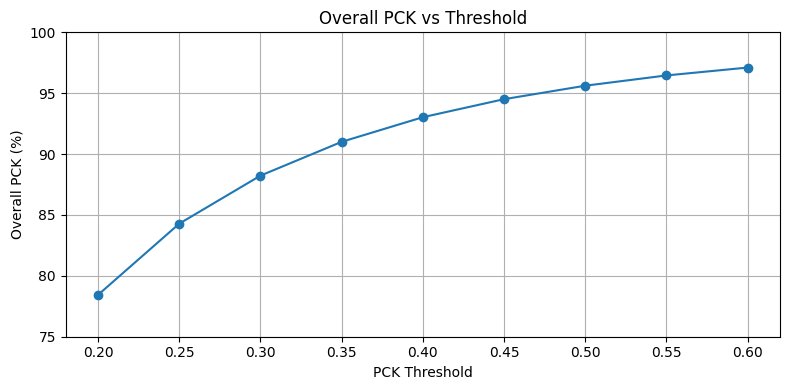

In [11]:
# Plot overall PCK percentage versus threshold
overall_pck_percent = []
valid_thresholds = []
for th in thresholds:
    values = pck_accum.get(th, [])
    if len(values) == 0:
        continue
    valid_thresholds.append(th)
    overall_pck_percent.append(np.mean(values) * 100)
if len(valid_thresholds) == 0:
    raise RuntimeError("No PCK data available to plot. Run the metric aggregation cells first.")
plt.figure(figsize=(8, 4))
plt.plot(valid_thresholds, overall_pck_percent, marker='o')
plt.xlabel('PCK Threshold')
plt.ylabel('Overall PCK (%)')
plt.title('Overall PCK vs Threshold')
plt.ylim(75, 100)
plt.grid(True)
plt.tight_layout()
plt.show()